<a href="https://colab.research.google.com/github/HarshPramodh/Business-Analytics-Projects/blob/main/Fraud_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report)

In [6]:
df=pd.read_csv("fraudTest.csv")

In [7]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767.0,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [8]:
df.shape

(81660, 23)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81660 entries, 0 to 81659
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             81660 non-null  int64  
 1   trans_date_trans_time  81660 non-null  object 
 2   cc_num                 81660 non-null  int64  
 3   merchant               81659 non-null  object 
 4   category               81659 non-null  object 
 5   amt                    81659 non-null  float64
 6   first                  81659 non-null  object 
 7   last                   81659 non-null  object 
 8   gender                 81659 non-null  object 
 9   street                 81659 non-null  object 
 10  city                   81659 non-null  object 
 11  state                  81659 non-null  object 
 12  zip                    81659 non-null  float64
 13  lat                    81659 non-null  float64
 14  long                   81659 non-null  float64
 15  ci

In [10]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,81660.000000,8.166000e+04,81659.000000,81659.000000,81659.000000,81659.00000,8.165900e+04,8.165900e+04,81659.000000,81659.000000,81659.000000
mean,40829.500000,4.167296e+17,69.323775,48800.344249,38.543669,-90.20351,8.920389e+04,1.373017e+09,38.541472,-90.204056,0.003747
std,23573.355828,1.308610e+18,152.790402,26843.839900,5.065402,13.69066,3.021621e+05,7.151736e+05,5.101057,13.703484,0.061101
min,0.000000,4.841314e+09,1.000000,1257.000000,20.027100,-165.67230,2.300000e+01,1.371817e+09,19.042320,-166.646251,0.000000
25%,20414.750000,1.800429e+14,9.630000,26237.000000,34.668900,-96.79090,7.430000e+02,1.372431e+09,34.756325,-96.876368,0.000000
50%,40829.500000,3.519607e+15,47.130000,48174.000000,39.371600,-87.47690,2.408000e+03,1.373044e+09,39.371583,-87.429817,0.000000
75%,61244.250000,4.634956e+15,82.810000,72011.000000,41.948800,-80.17520,2.032800e+04,1.373654e+09,41.961760,-80.257202,0.000000
max,81659.000000,4.992346e+18,13149.150000,99783.000000,65.689900,-67.95030,2.906700e+06,1.374271e+09,66.669356,-66.952352,1.000000


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,1
category,1
amt,1
first,1
last,1
gender,1
street,1


In [12]:
# Exploratory Data Analysis
df['is_fraud'].value_counts()


,count
is_fraud,
0.0,81353
1.0,306


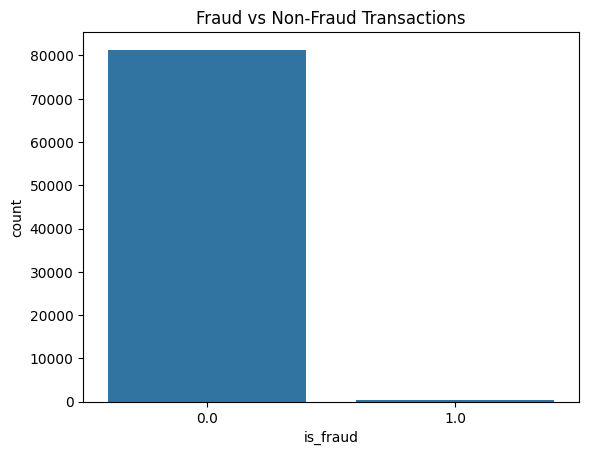

In [13]:
sns.countplot(
    x='is_fraud',
    data=df
)

plt.title('Fraud vs Non-Fraud Transactions')

plt.show()

In [14]:
#Which category has highest frauds
fraud_category = df[df['is_fraud']==1]

fraud_category['category'].value_counts()

,count
category,
shopping_net,71
grocery_pos,71
shopping_pos,33
misc_net,31
gas_transport,17
misc_pos,12
home,12
food_dining,10
personal_care,9


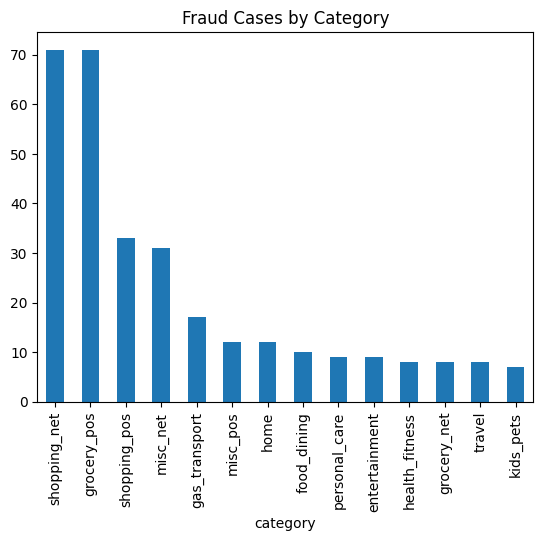

In [15]:
fraud_category['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fraud Cases by Category")

plt.show()

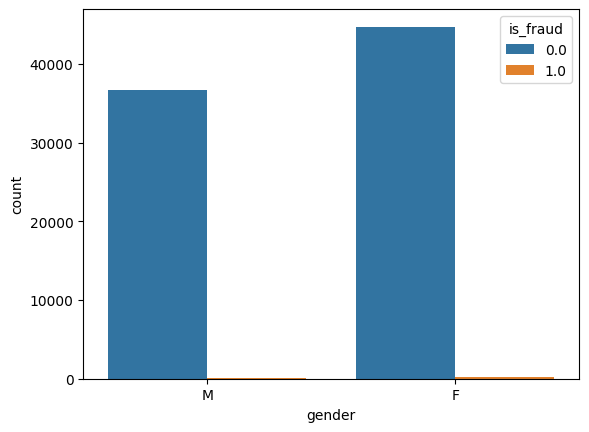

In [16]:
# Fraud by Gender
sns.countplot(
    x='gender',
    hue='is_fraud',
    data=df
)

plt.show()

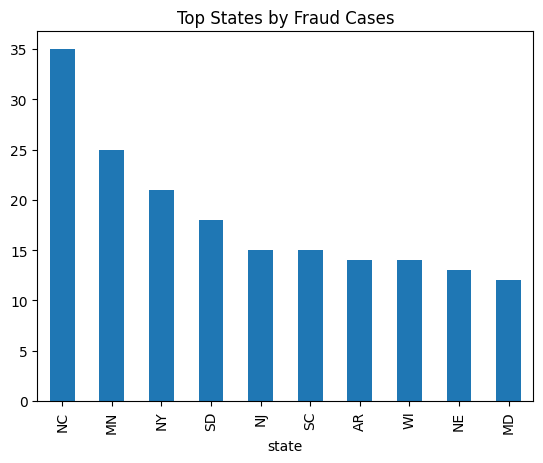

In [17]:
# Fraud by State
state_fraud = fraud_category['state'].value_counts().head(10)

state_fraud.plot(
    kind='bar'
)

plt.title("Top States by Fraud Cases")

plt.show()

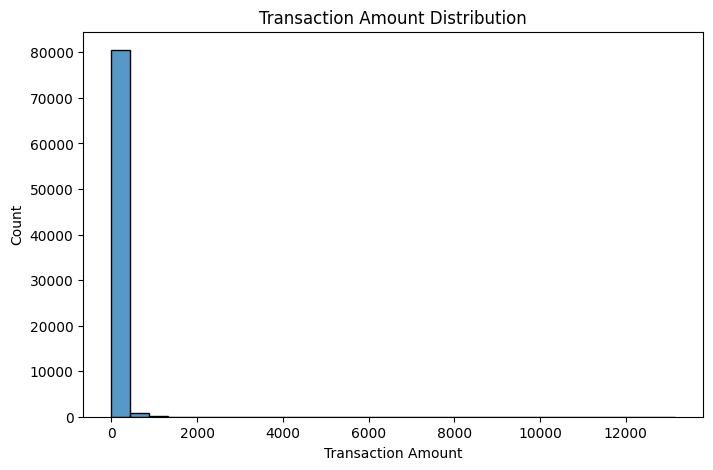

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['amt'], bins=30)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Amount")

plt.show()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81660 entries, 0 to 81659
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             81660 non-null  int64  
 1   trans_date_trans_time  81660 non-null  object 
 2   cc_num                 81660 non-null  int64  
 3   merchant               81659 non-null  object 
 4   category               81659 non-null  object 
 5   amt                    81659 non-null  float64
 6   first                  81659 non-null  object 
 7   last                   81659 non-null  object 
 8   gender                 81659 non-null  object 
 9   street                 81659 non-null  object 
 10  city                   81659 non-null  object 
 11  state                  81659 non-null  object 
 12  zip                    81659 non-null  float64
 13  lat                    81659 non-null  float64
 14  long                   81659 non-null  float64
 15  ci

In [20]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
]

df = df.drop(columns=drop_cols)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81660 entries, 0 to 81659
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   merchant    81659 non-null  object 
 1   category    81659 non-null  object 
 2   amt         81659 non-null  float64
 3   gender      81659 non-null  object 
 4   city        81659 non-null  object 
 5   state       81659 non-null  object 
 6   zip         81659 non-null  float64
 7   lat         81659 non-null  float64
 8   long        81659 non-null  float64
 9   city_pop    81659 non-null  float64
 10  job         81659 non-null  object 
 11  dob         81659 non-null  object 
 12  unix_time   81659 non-null  float64
 13  merch_lat   81659 non-null  float64
 14  merch_long  81659 non-null  float64
 15  is_fraud    81659 non-null  float64
dtypes: float64(9), object(7)
memory usage: 10.0+ MB


In [22]:
df['is_fraud'].unique()

array([ 0.,  1., nan])

In [23]:
df = df.dropna(subset=['is_fraud'])

In [24]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [27]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
lr_pred = lr.predict(X_test)

In [35]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95     16271
         1.0       0.03      0.80      0.06        61

    accuracy                           0.91     16332
   macro avg       0.52      0.86      0.51     16332
weighted avg       1.00      0.91      0.95     16332



In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16271
         1.0       0.61      0.64      0.62        61

    accuracy                           1.00     16332
   macro avg       0.80      0.82      0.81     16332
weighted avg       1.00      1.00      1.00     16332



In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16271
         1.0       0.69      0.41      0.52        61

    accuracy                           1.00     16332
   macro avg       0.85      0.70      0.76     16332
weighted avg       1.00      1.00      1.00     16332



In [38]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'KNN'
    ],

    'Precision':[
        0.03,
        0.61,
        0.69
    ],

    'Recall':[
        0.80,
        0.64,
        0.41
    ],

    'F1 Score':[
        0.06,
        0.62,
        0.52
    ]
})

results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.03,0.80,0.06
1,Decision Tree,0.61,0.64,0.62
2,KNN,0.69,0.41,0.52


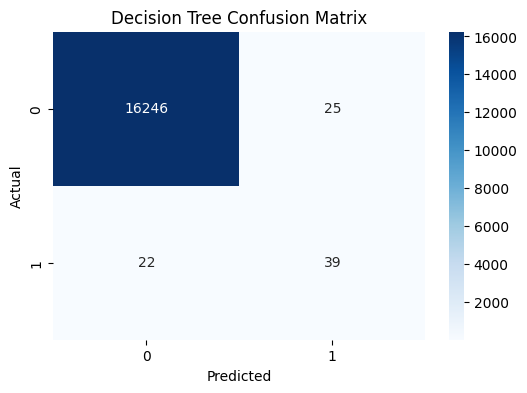

In [39]:


cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()